# Interactive InSAR time-series viewers

this code run on one folder - for auto-folders processing, go to autoloop one

In [15]:
from pathlib import Path
from datetime import datetime
from functools import lru_cache
import re
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
import numpy as np
import panel as pn
import rasterio
from IPython.display import display

#pn.extension(comms="ipywidgets")
pn.extension()

In [17]:
# Change only this path when using a different dataset.

# ---------
# root = Path(
#     "/Volumes/shared/Sci-EAE/lahuang_work/working/5062_InSAR"
# )

#export_folder = root / "time_series_exports"

# export_folder.mkdir(parents=True, exist_ok=True)

# # ---------
# root = Path(
#     "/Volumes/shared/Sci-EAE/lahuang_work/working/Fastice_analyse_m3_results/Sentinel/Casey/5062_InSAR"
# )

# export_folder = Path(
#     "/Volumes/shared/Sci-EAE/lahuang_work/working/"
#     "Fastice_analyse_m3_results/time_series_figures/Casey/5062_InSAR"
# )

# export_folder.mkdir(parents=True, exist_ok=True)

# ---------
base_folder = Path(
    "/Volumes/shared/Sci-EAE/lahuang_work/working/"
    "Fastice_analyse_m3_results"
)

relative_folder = Path("Casey/5062_InSAR")

root = base_folder / "Sentinel" / relative_folder
export_folder = base_folder / "time_series_figures" / relative_folder

export_folder.mkdir(parents=True, exist_ok=True)
# ---------

#-----------read files-------------------------

files = {
    "phase_boundary": "filt_topophase_phase_geo_fast_ice_boundary.png",
    "amplitude_boundary": "topophase_amp_geo_fast_ice_boundary.png",
    "coherence_boundary": "topophase_coherence_geo_fast_ice_boundary.png",
    "coherence_only_png": "topophase_coherence_geo_fast_ice_only.png",
    "coherence_only_tif": "topophase_coherence_geo_fast_ice_only.tif",
}

IMAGE_WIDTH = 500
PLAYER_WIDTH = 500
PLAYER_INTERVAL = 600

if not root.is_dir():
    raise NotADirectoryError(f"Folder not found: {root}")


Found 11 InSAR folders
Casey/5062_InSAR
Casey/ACBB_InSAR
Davis/A97C_InSAR
Davis/D5D5_InSAR
EastShackleton/0E6C_InSAR
EastShackleton/5833_InSAR
Mawson/A7E3_InSAR
Mawson/AF34_InSAR
Shackleton/7989_InSAR
Syowa/5595_InSAR
Syowa/EE9E_InSAR


In [3]:
# Scan every maskInSAR folder once.
datasets = []

for mask_folder in sorted(root.rglob("maskInSAR")):
    pair_name = mask_folder.parent.name
    match = re.search(r"_(\d{8}T\d{6})_(\d{8}T\d{6})", pair_name)

    if not match:
        print(f"Skipped: cannot extract dates from {pair_name}")
        continue

    paths = {key: mask_folder / name for key, name in files.items()}
    missing = [path.name for path in paths.values() if not path.is_file()]

    if missing:
        print(f"Skipped {pair_name}; missing: {', '.join(missing)}")
        continue

    datasets.append({
        "pair_name": pair_name,
        "first_time": datetime.strptime(match.group(1), "%Y%m%dT%H%M%S"),
        "second_time": datetime.strptime(match.group(2), "%Y%m%dT%H%M%S"),
        **paths,
    })

datasets.sort(key=lambda item: (item["first_time"], item["second_time"]))

if not datasets:
    raise FileNotFoundError(f"No complete datasets found under {root}")

print(f"Found {len(datasets)} complete datasets")
for index, item in enumerate(datasets):
    print(f"{index:02d}: {item['first_time']:%Y-%m-%d %H:%M} → {item['second_time']:%Y-%m-%d %H:%M}")

Found 6 complete datasets
00: 2026-04-06 12:35 → 2026-04-18 12:35
01: 2026-04-18 12:35 → 2026-04-30 12:36
02: 2026-04-30 12:36 → 2026-05-12 12:36
03: 2026-05-12 12:36 → 2026-05-24 12:36
04: 2026-05-24 12:36 → 2026-06-05 12:36
05: 2026-07-06 12:36 → 2026-07-18 12:36


In [4]:
# Shared helper functions used by both viewers.
def date_heading(item):
    return pn.pane.Markdown(
        f"## {item['first_time']:%Y-%m-%d %H:%M} → {item['second_time']:%Y-%m-%d %H:%M}"
    )


def png_pane(path):
    return pn.pane.PNG(str(path), width=IMAGE_WIDTH, fixed_aspect=True)


def build_viewer(frame_function):
    player = pn.widgets.Player(
        name="Time", start=0, end=len(datasets) - 1, value=0, step=1,
        interval=PLAYER_INTERVAL, width=PLAYER_WIDTH,
    )
    content = pn.bind(frame_function, frame=player)
    return pn.Column(player, content, width=IMAGE_WIDTH + 30)


@lru_cache(maxsize=None)
def coherence_histogram(tif_path):
    with rasterio.open(tif_path) as source:
        coherence = source.read(1, masked=True)

    values = coherence.compressed()
    values = values[np.isfinite(values)]
    values = values[(values >= 0) & (values <= 1)]

    fig, axis = plt.subplots(figsize=(7, 3.2))
    axis.hist(values, bins=50, range=(0, 1), color="steelblue", edgecolor="black", linewidth=0.4)
    axis.set_xlim(0, 1)
    axis.set_xlabel("Coherence")
    axis.set_ylabel("Number of pixels")
    axis.grid(alpha=0.25)
    fig.tight_layout()
    plt.close(fig)
    return fig

## Viewer 1: filtered topophase and amplitude

In [5]:
def show_phase_amplitude(frame):
    item = datasets[frame]
    return pn.Column(
        date_heading(item),
        pn.pane.Markdown("### Filtered topophase with fast-ice boundary"),
        png_pane(item["phase_boundary"]),
        pn.pane.Markdown("### Amplitude with fast-ice boundary"),
        png_pane(item["amplitude_boundary"]),
    )

phase_amplitude_viewer = build_viewer(show_phase_amplitude)
#display(pn.ipywidget(phase_amplitude_viewer))
pn.ipywidget(phase_amplitude_viewer)

BokehModel(combine_events=True, render_bundle={'docs_json': {'50ce56bf-1c28-47db-bd09-cc5723a4112b': {'version…

UnknownReferenceError: can't resolve reference 'a617ec60-bbf5-4c43-8625-b41f4c57922b'

UnknownReferenceError: can't resolve reference '10d92d71-93f9-45bd-9d76-9a676451fed5'

## Viewer 2: coherence images and distribution

In [6]:
def show_coherence(frame):
    item = datasets[frame]
    histogram = coherence_histogram(str(item["coherence_only_tif"]))

    return pn.Column(
        date_heading(item),
        pn.pane.Markdown("### Coherence with fast-ice boundary"),
        png_pane(item["coherence_boundary"]),
        pn.pane.Markdown("### Coherence inside the fast-ice area"),
        png_pane(item["coherence_only_png"]),
        pn.pane.Markdown("### Coherence value distribution"),
        pn.pane.Matplotlib(histogram, width=IMAGE_WIDTH, tight=True),
    )

coherence_viewer = build_viewer(show_coherence)
#display(pn.ipywidget(coherence_viewer))
pn.ipywidget(coherence_viewer)

# coherence_viewer = build_viewer(show_coherence)
# display(coherence_viewer)

BokehModel(combine_events=True, render_bundle={'docs_json': {'57b45456-273b-44dd-baee-2cb2a2bc2f9b': {'version…

In [7]:


# ---------------------------------------------------------
# Save interactive HTML viewers
# ---------------------------------------------------------

phase_amplitude_viewer.save(
    export_folder / "interactive_phase_amplitude.html",
    embed=True,
    resources="inline",
    embed_json=False,
    max_states=50,
    max_opts=len(datasets)
)

coherence_viewer.save(
    export_folder / "interactive_coherence.html",
    embed=True,
    resources="inline",
    embed_json=False,
    max_states=50,
    max_opts=len(datasets)
)

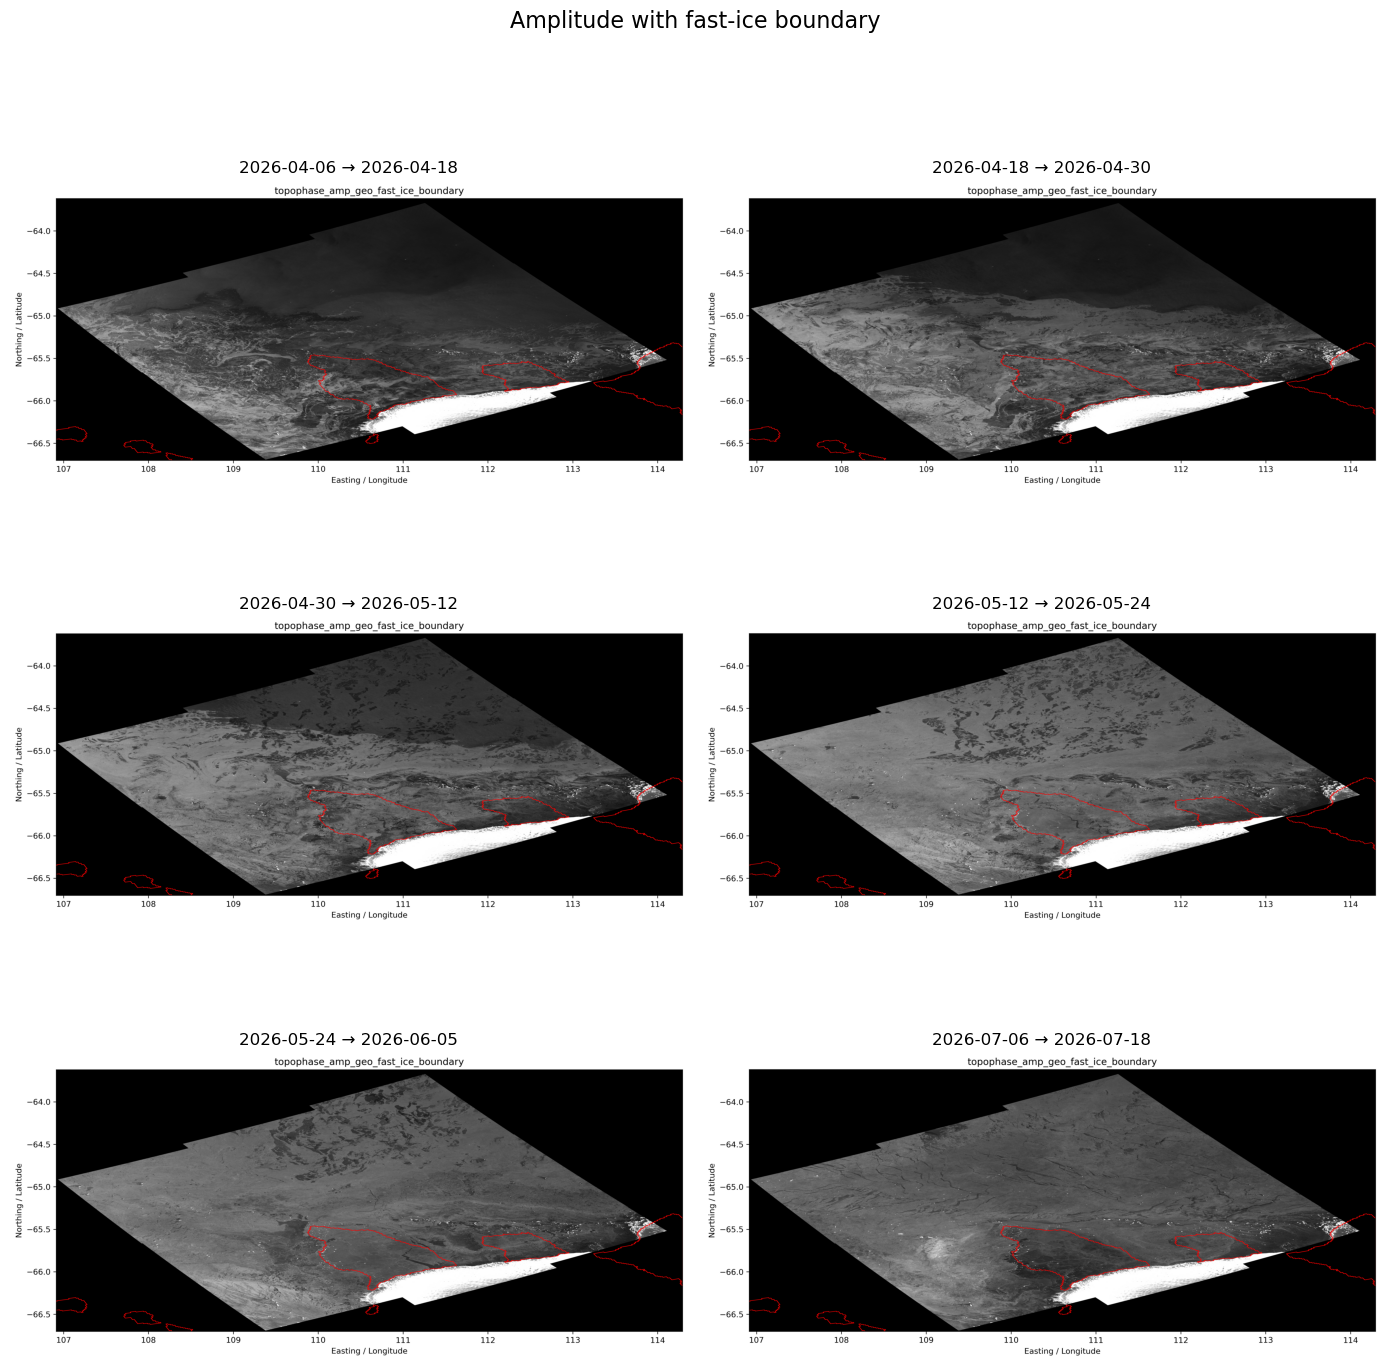

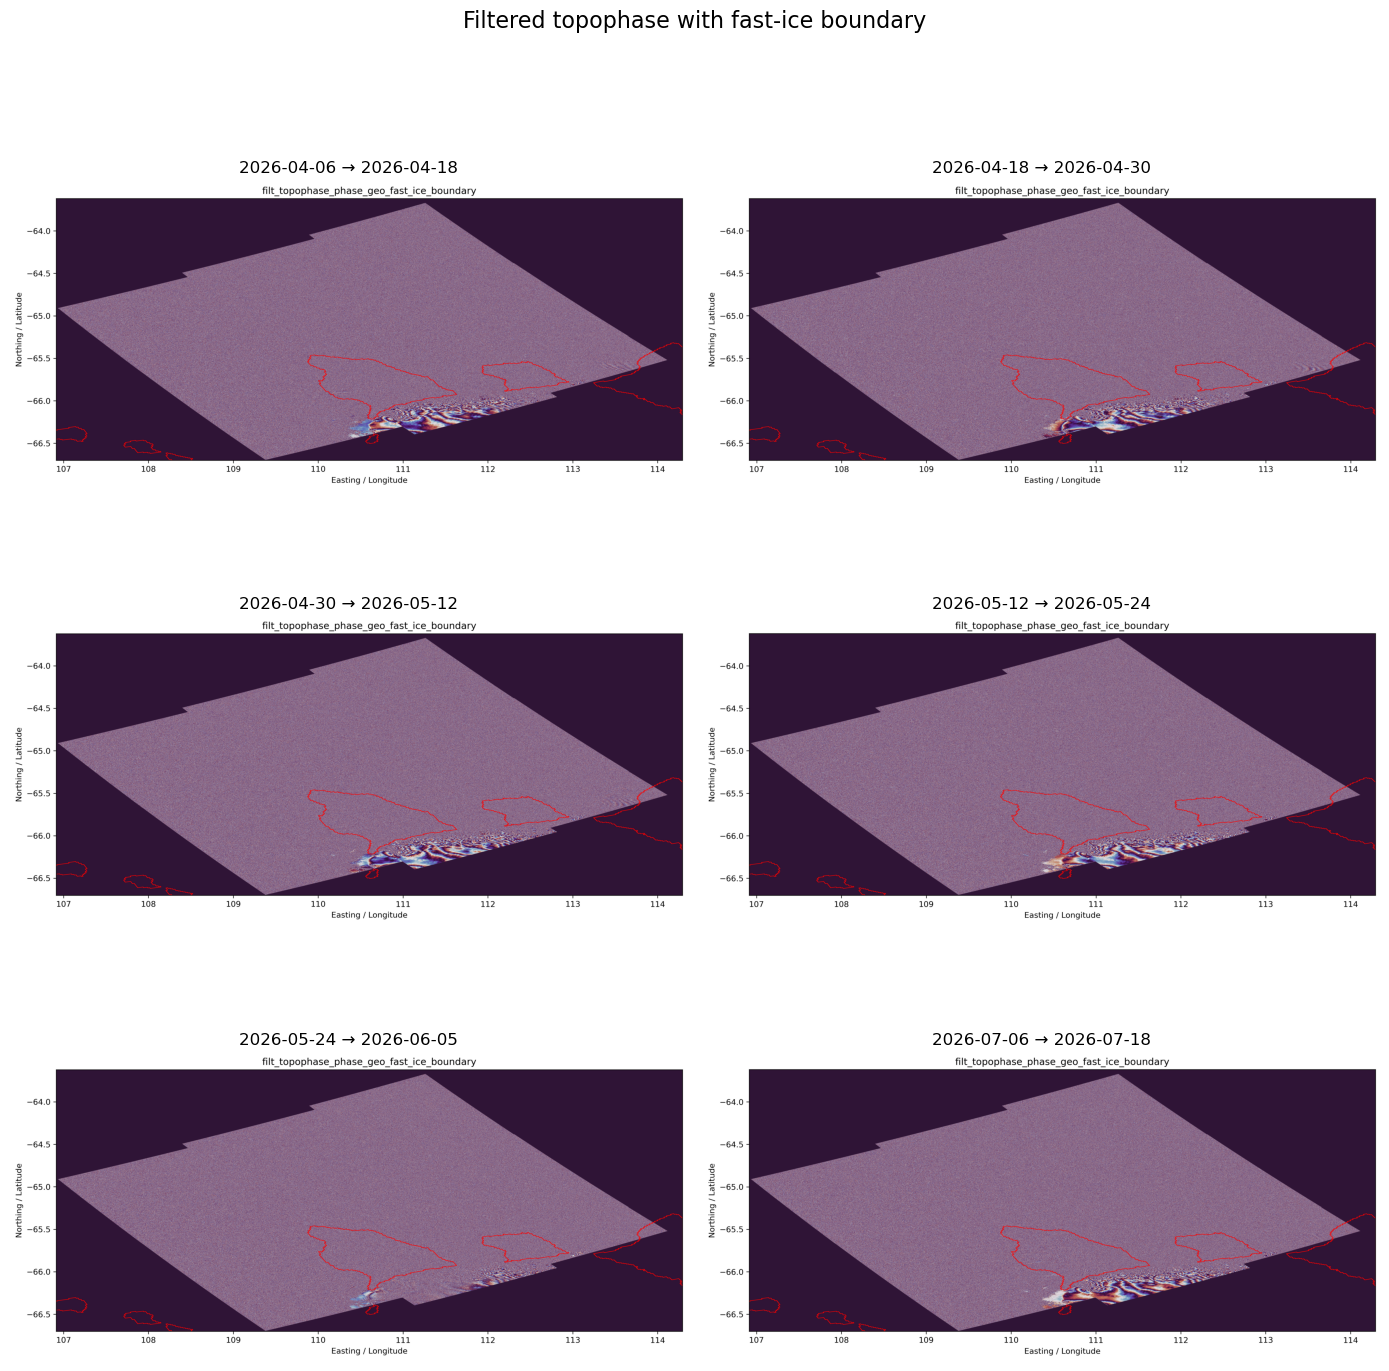

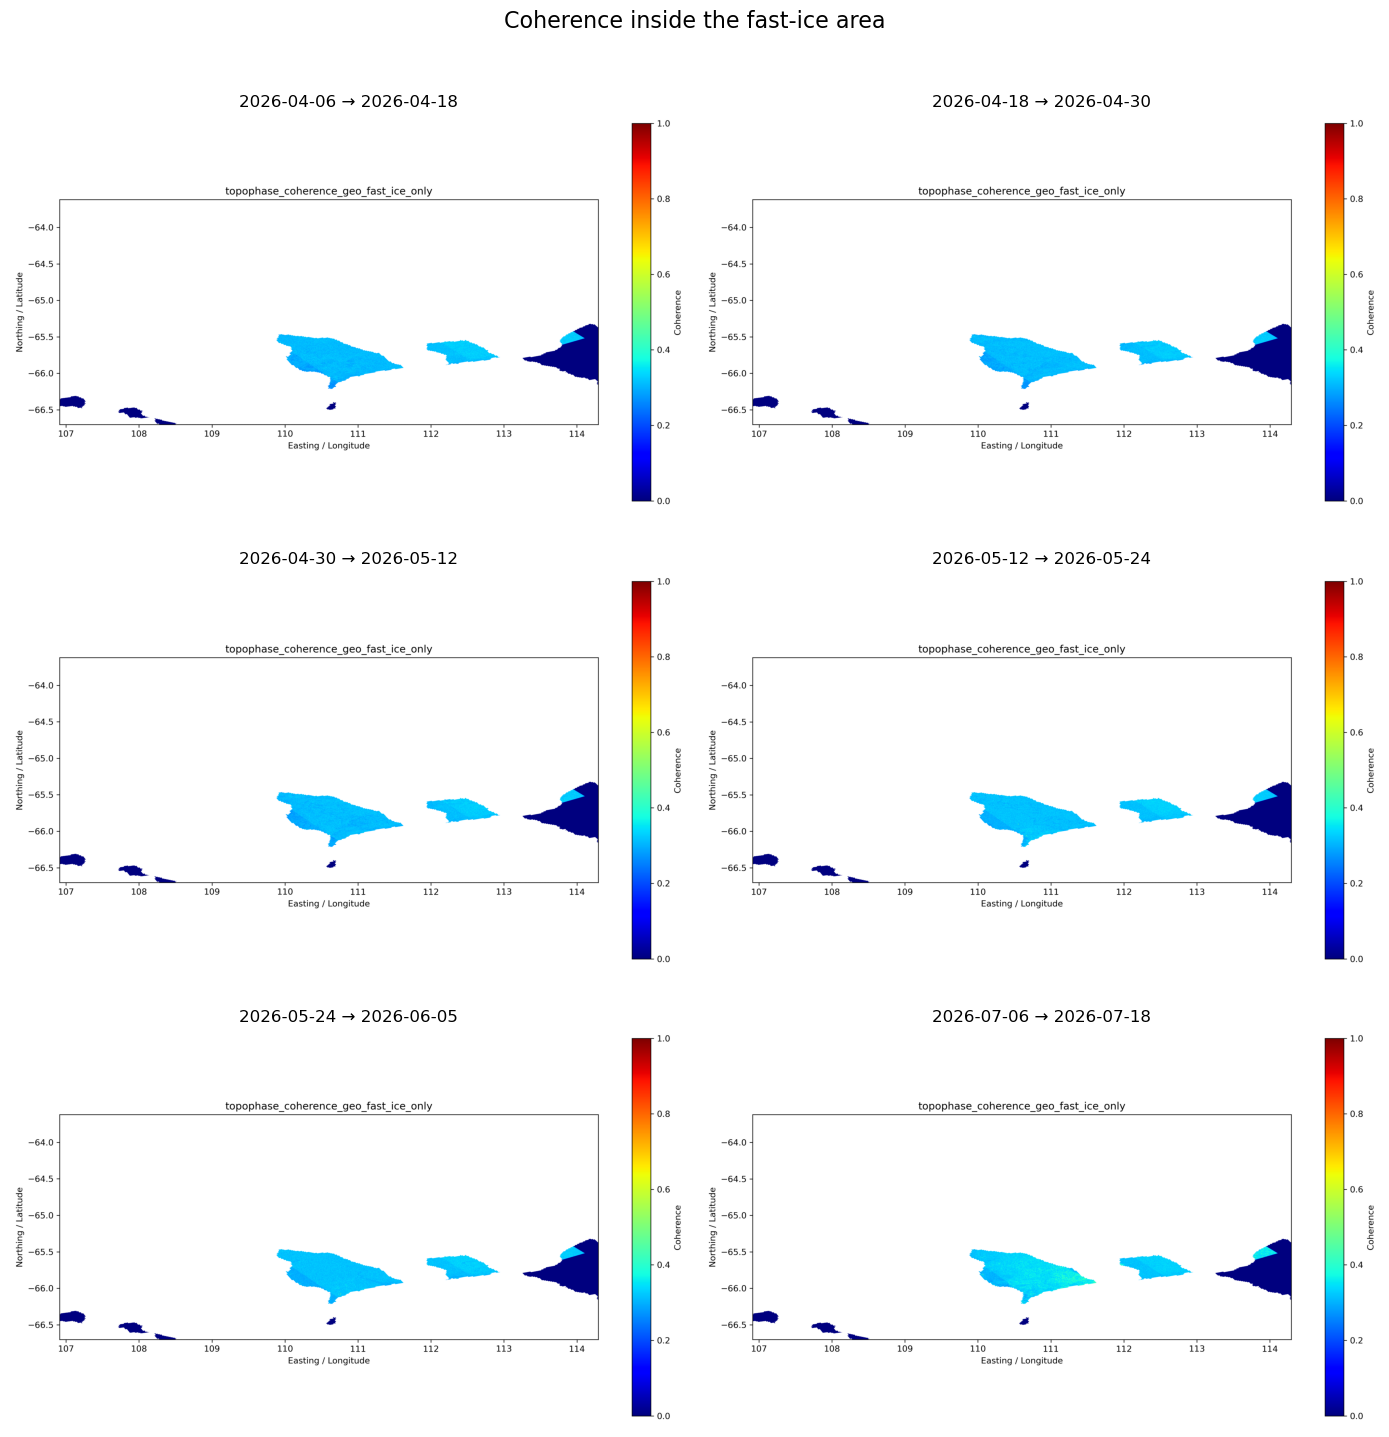

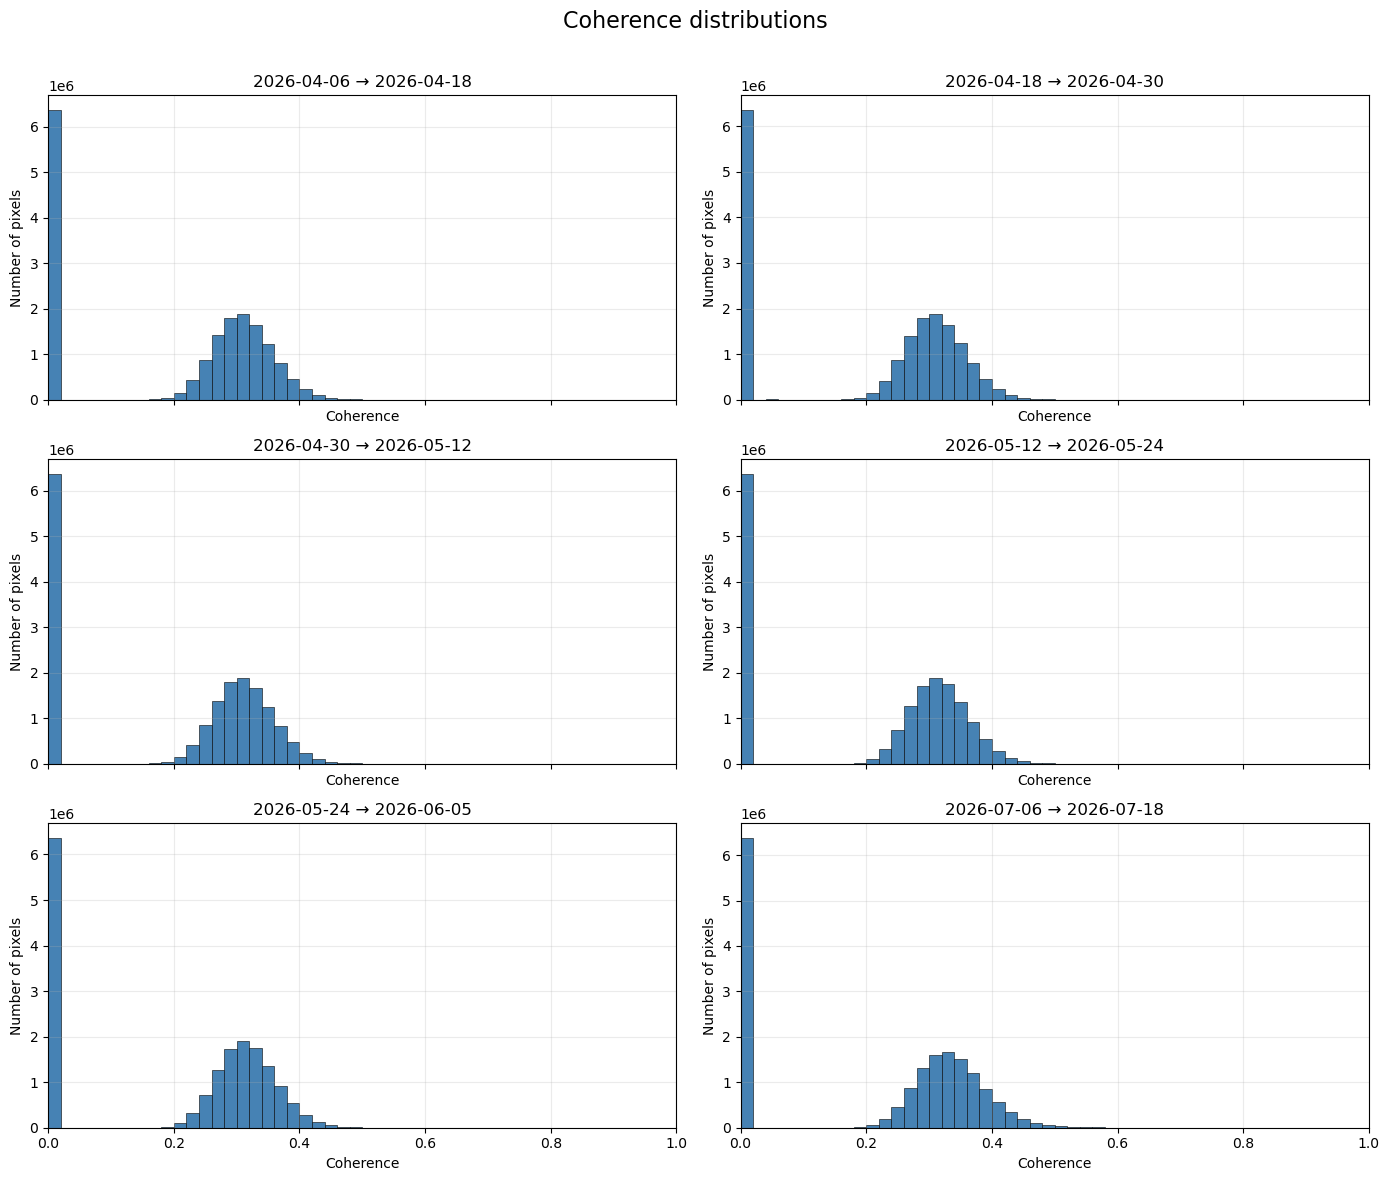

In [8]:
# Four overview figures. This reuses the existing `datasets` list.
ncols = 2
nrows = int(np.ceil(len(datasets) / ncols))


def short_date(item):
    return (
        f"{item['first_time']:%Y-%m-%d}"
        f" → {item['second_time']:%Y-%m-%d}"
    )


def plot_all_pngs(file_key, figure_title, output_name):
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for axis, item in zip(axes, datasets):
        axis.imshow(plt.imread(item[file_key]))
        axis.set_title(short_date(item))
        axis.axis("off")

    for axis in axes[len(datasets):]:
        axis.axis("off")

    fig.suptitle(figure_title, fontsize=16)
    fig.tight_layout(rect=(0, 0, 1, 0.97))

    fig.savefig(
        export_folder / output_name,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    #plt.close(fig)


plot_all_pngs(
    "amplitude_boundary",
    "Amplitude with fast-ice boundary",
    "all_amplitude.png"
)

plot_all_pngs(
    "phase_boundary",
    "Filtered topophase with fast-ice boundary",
    "all_filtered_topophase.png"
)

plot_all_pngs(
    "coherence_only_png",
    "Coherence inside the fast-ice area",
    "all_coherence_fast_ice_only.png"
)

# Figure 4: one coherence histogram for every date pair
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows), sharex=True)
axes = np.atleast_1d(axes).ravel()

for axis, item in zip(axes, datasets):
    with rasterio.open(item["coherence_only_tif"]) as source:
        values = source.read(1, masked=True).compressed()

    values = values[np.isfinite(values)]
    values = values[(values >= 0) & (values <= 1)]

    axis.hist(
        values, bins=50, range=(0, 1),
        color="steelblue", edgecolor="black", linewidth=0.4,
    )
    axis.set_xlim(0, 1)
    axis.set_title(short_date(item))
    axis.set_xlabel("Coherence")
    axis.set_ylabel("Number of pixels")
    axis.grid(alpha=0.25)

for axis in axes[len(datasets):]:
    axis.axis("off")

# plot the histogram of coherence values
fig.suptitle("Coherence distributions", fontsize=16)
fig.tight_layout(rect=(0, 0, 1, 0.97))

fig.savefig(
    export_folder / "all_coherence_histograms.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

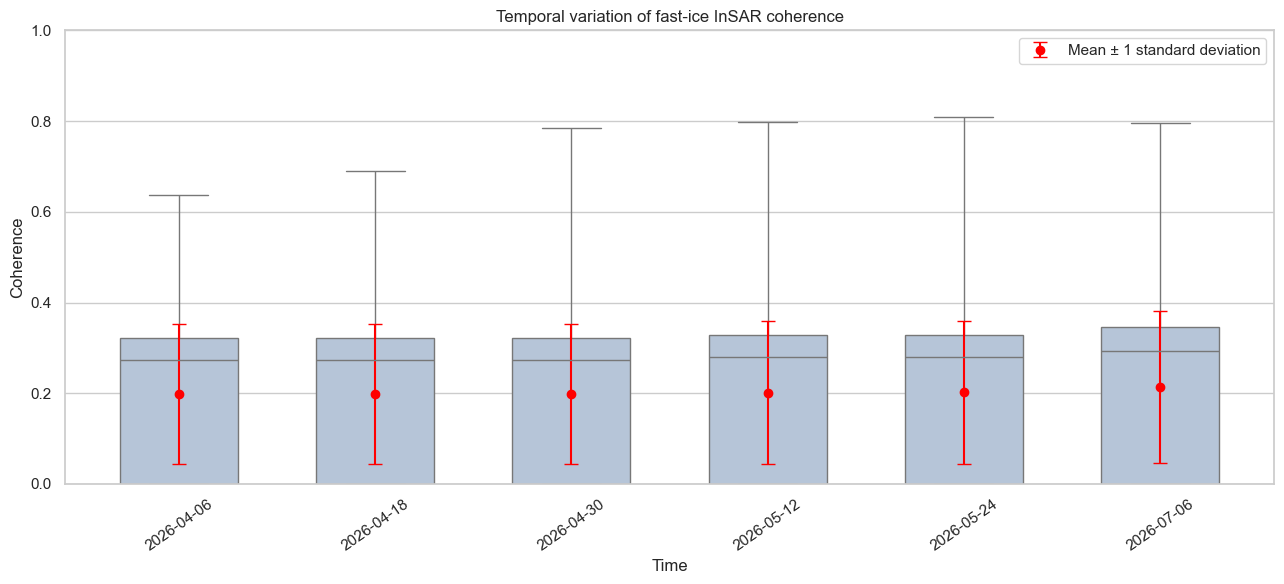

In [14]:
boxplot_records = []
coherence_statistics = []

for item in datasets:

    with rasterio.open(item["coherence_only_tif"]) as source:
        values = source.read(1, masked=True).compressed()

    values = values[np.isfinite(values)]
    values = values[(values >= 0) & (values <= 1)]

    startpoint = (
        item["first_time"]

    )

    date_label = startpoint.strftime("%Y-%m-%d")

    coherence_statistics.append(
        {
            "date": date_label,
            "mean": np.mean(values),
            "std": np.std(values),
        }
    )

    # Use all valid pixels
    boxplot_records.extend(
        {
            "date": date_label,
            "coherence": value,
        }
        for value in values
    )


# plot boxplot of coherence values over time
boxplot_data = pd.DataFrame(boxplot_records)
statistics_data = pd.DataFrame(coherence_statistics)


# Plot
sns.set_theme(style="whitegrid")

fig, axis = plt.subplots(figsize=(13, 6))

sns.boxplot(
    data=boxplot_data,
    x="date",
    y="coherence",
    color="lightsteelblue",
    width=0.6,
    showfliers=False,
    ax=axis,
)

# Add mean ± one standard deviation
x_positions = np.arange(len(statistics_data))

axis.errorbar(
    x=x_positions,
    y=statistics_data["mean"],
    yerr=statistics_data["std"],
    fmt="o",
    color="red",
    ecolor="red",
    capsize=5,
    markersize=6,
    linewidth=1.5,
    label="Mean ± 1 standard deviation",
)

axis.set_ylim(0, 1)
axis.set_xlabel("Time")
axis.set_ylabel("Coherence")
axis.set_title("Temporal variation of fast-ice InSAR coherence")
axis.tick_params(axis="x", rotation=35)
axis.legend()

fig.tight_layout()
plt.savefig(
    export_folder / "coherence_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()